<a href="https://colab.research.google.com/github/NguyenLe15325/My-random-notebook/blob/main/6_7960_Fall_2024_hw2_gnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Basic pre-reqs:

import torch


def format_pytorch_version(version):
  return version.split('+')[0]

TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)

def format_cuda_version(version):
  return 'cu' + version.replace('.', '')

CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)


!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric

import numpy as np
from torch.autograd import Variable
from matplotlib import pyplot as plt
import torch
from torch import nn
import math
from torch.functional import F
from torch.optim import Adam
from torch_geometric.nn import MessagePassing, global_max_pool
from torchvision import datasets, transforms
from torch_geometric.data import Data, DataLoader
import torch.utils.data as data_utils
import torch_geometric
from torch_scatter import scatter_max
import dataclasses
import networkx as nx
from typing import *
from tqdm import tqdm
import os
import jax
from scipy.integrate import odeint
from torch_geometric.nn import GCNConv
import copy

from torch_geometric.utils import add_self_loops, degree, remove_self_loops

NUM_EPOCHS = 20
LR = 5e-4
device = torch.device("cuda")
%matplotlib inline

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 40.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 32.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_spline_conv: filename=torch_spline_conv-1.2.2-cp312-cp312-linux_x86_64.whl size=718522 sha256=04f2c38b797532f1429aa7ca539f70dd7589f93e8fd3314d953abccc316b6d34
  Stored in directory: /root/.cache/pip/wheels/54/7a/2e/46a729dc0aad2da1a908b0d2ac86ab127d73e6b4310a945d07
Successfully built torch_spline_conv
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.5 MB/s eta 0:00:00



## Training Utilities

In [2]:

@dataclasses.dataclass
class TrainResult:
    r"""
    A collection containing everything we need to know about the training results
    """

    num_epochs: int
    lr: float

    # The trained model
    model: nn.Module

    # Training loss (saved at each iteration in `train_epoch`)
    train_losses: List[float]

    # Training accuracies, before training and after each epoch
    train_accs: List[float]

    # Validation accuracies, before training and after each epoch
    val_accs: List[float]

def learning_curve(result: TrainResult, *, title: str = 'Learning Curve'):
    r"""
    Plot the training loss, training accuracy, and validation accuracy versus
    epochs taken.
    """
    fig, ax_loss = plt.subplots(figsize=(8, 5))
    ax_loss.set_title(title, fontsize=16)
    ax_loss.set_xlabel('Epoch', fontsize=12)

    l_trloss = ax_loss.plot(
        torch.arange(len(result.train_losses)) / len(result.train_losses) * result.num_epochs,
        result.train_losses,
        label='Train loss',
        color='C0',
    )
    ax_loss.set_ylim(0, max(result.train_losses))
    ax_loss.set_ylabel('Train loss', color='C0', fontsize=12)
    ax_loss.tick_params(axis='y', labelcolor='C0')

    ax_acc = ax_loss.twinx()
    if len(result.val_accs):
        l_valacc = ax_acc.plot(result.val_accs, label='Val', color='C1')
    else:
        l_valacc = ()
    ax_acc.set_ylim(0, max(max(result.val_accs), 1))
    ax_acc.set_ylabel('Validation', color='C1', fontsize=12)
    ax_acc.tick_params(axis='y', labelcolor='C1')

    lines = l_trloss + l_valacc

    ax_loss.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=13)

def train_nn(model, train_dataset, test_dataset, batch_size=32, num_epochs=NUM_EPOCHS, lr=LR, graph=True, criterion=nn.CrossEntropyLoss(), regression=True):

    train_result = TrainResult(num_epochs, lr, model, train_losses = [], train_accs=[], val_accs=[])

    if(graph):
        train_loader = torch_geometric.loader.DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
        test_loader = torch_geometric.loader.DataLoader(test_dataset, batch_size = batch_size, shuffle=False)
    else:
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    total_train = 0
    for epoch in range(num_epochs):

        model.train()
        for datapoint in tqdm(train_loader):
            if(graph):
                datapoint = datapoint.to(device)
                X, y = datapoint, datapoint.y
            else:
                X, y = datapoint[0].to(device), datapoint[1].to(device)
            optimizer.zero_grad()
            output = model(X)

            loss = criterion(output, y)
            train_result.train_losses.append(loss.item())
            total_train += loss.item()
            loss.backward()
            optimizer.step()

        total_train = total_train/len(train_loader)

        model.eval()
        total_val = 0
        with torch.no_grad():
            for bidx, datapoint in enumerate(test_loader):
                if(graph):
                    datapoint = datapoint.to(device)
                    X, y = datapoint, datapoint.y
                else:
                    X, y = datapoint[0].to(device), datapoint[1].to(device)
                output = model(X)
                if(regression):
                    total_val += criterion(output, y).item()
                else:
                    total_val += torch.sum(torch.argmax(output, dim=-1)==y).item()/output.size(dim=0)
        train_result.val_accs.append(total_val/len(test_loader))

        if(regression):
            print("Epoch {}: Train Loss={} Validation Loss={}".format(epoch, total_train, train_result.val_accs[-1]))
        else:
            print("Epoch {}: Train Loss={} Validation Accuracy={}%".format(epoch, total_train, train_result.val_accs[-1]*100))

    return train_result

## GNN Architecture

Graph neural networks subscribe to a slightly different API from [pytorch geometric](https://pytorch-geometric.readthedocs.io/en/latest/). In addition to the input features of shape [N, in_channels] for N nodes and `in_channels` node features per node, they also expect an edge_index tensor of shape [2, E] for E edges that specifies the *structure* of the graph.

Instead of sliding window convolutions used in the CNN, Graph neural networks use graph convolutions implemented via message passing. There are many ways to aggregate and normalize messages during graph convolutions. Here we will be using [Graph Convolutional Networks](https://arxiv.org/abs/1609.02907) (GCN).

GCNs normalize the messages by *both* the degrees from the source node and target node. More specifically, GCN message passing has the following form.

$$x_i^{(k)} = \sum_{j\in{\mathcal{N}(i)\cup{\{i\}}}}C\Big(W\cdot{x_j^{(k-1)}}\Big)+b$$


$$C=\frac{1}{\sqrt{\text{deg}(i)}\cdot\sqrt{\text{deg}(j)}}$$

Read the following code to see how a graph convolutional layer can be implemented. These layers are then interleaved with ReLU nonlinearities and then passed through `scatter_max` ([docs](https://pytorch-scatter.readthedocs.io/en/1.3.0/functions/max.html)). Think about:
  - Why is `scatter_max` needed (Hint: try not including it and see what happens)?
  - How does `scatter_max` alter the shape of the activations

In [3]:

class GCNConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_channels, out_channels, bias=False)
        self.bias = nn.Parameter(torch.Tensor(out_channels))

        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        self.bias.data.zero_()

    def forward(self, x, edge_index):
        # x has shape [N, in_channels]
        # edge_index has shape [2, E]
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        x = self.lin(x)

        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)

        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]


        out = self.propagate(edge_index, x=x, norm=norm)
        out += self.bias

        return out

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

class GNN(torch.nn.Module):
    def __init__(self, in_channels=3, out_channels = 10):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, 32)
        self.conv3 = GCNConv(32, 48)
        self.conv4 = GCNConv(48, 64)
        self.linear1 = torch.nn.Linear(64,64)
        self.linear2 = torch.nn.Linear(64,out_channels)

    def forward(self, data):
        # Graph convolutional layers
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = F.relu(x)

        # scatter_max
        x, _ = scatter_max(x, data.batch, dim=0)

        # linear
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return  x

### Visualizing the GNN Architecture Input

To understand how the GNN processes data, let's visualize the graph structure of a sample molecule from our `graph_dataset`.

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

# Take a sample molecule from the graph_dataset
# Ensure graph_dataset is populated before running this cell
if 'graph_dataset' in locals() and len(graph_dataset) > 0:
    sample_graph_data = graph_dataset[0]

    # Convert to NetworkX graph
    # The edge_index is (2, E), where E is the number of edges. It contains (source, target) pairs.
    # We need to convert it to a list of (source, target) tuples.
    edges = sample_graph_data.edge_index.t().tolist()
    nx_graph = nx.Graph()
    nx_graph.add_edges_from(edges)

    # Optionally, add node features if they exist and are useful for visualization
    # For simplicity, we'll just plot the structure here.

    plt.figure(figsize=(8, 6))
    nx.draw_networkx(nx_graph, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_weight='bold')
    plt.title("Sample Molecule Graph Structure (Input to GNN)")
    plt.axis('off')
    plt.show()
else:
    print("graph_dataset is not yet available or is empty. Please ensure the data loading cell has been run.")

# Molecules

In this problem we will be trying to predict water solubility of a molecule from its chemical structure. The water solubility of a molecule is a measure of the amount of chemical substance that can dissolve in water at a specific temperature. The unit of  solubility is in mg/L.

Molecules can be represented in a graph structure in which the nodes are atoms and the edges are bonds between atoms or as an image in the form of a SMILES line notation. Both representations have the same information.

Fill in the rest of the code.

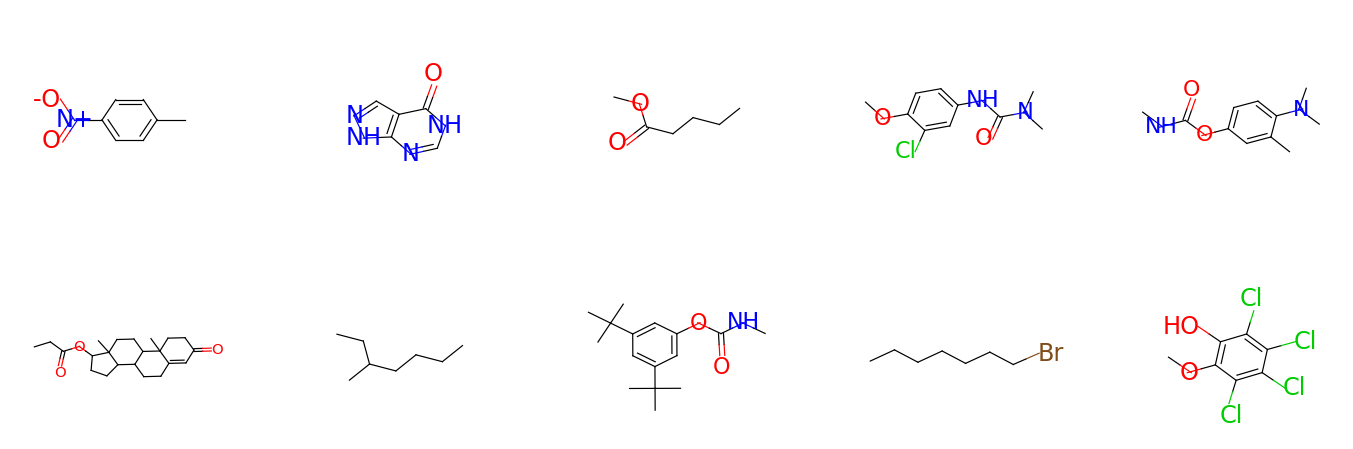

In [23]:
import sys
!{sys.executable} -m pip install rdkit

from torch_geometric.datasets import MoleculeNet
from torchdrug import data as tddata
# Temporarily comment out image visualization imports due to rdkit compatibility issue
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
from IPython.display import clear_output

dataset = MoleculeNet(root='/tmp/ESOL', name='ESOL')
dataset = dataset.shuffle()

graph_dataset = []
image_dataset = []
data_els = []
for data_el in tqdm(dataset):
    try:
        mol = tddata.Molecule.from_smiles(data_el.smiles)
    except:
        continue

    # Temporarily comment out image visualization code
    # fig = Figure(figsize=(2, 2))
    # canvas = FigureCanvas(fig)
    # ax = fig.gca()

    # ax.axis('off')
    # p = mol.visualize(ax=ax)
    # canvas.draw()       # draw the canvas, cache the renderer

    # image_from_plot = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    # image_from_plot = image_from_plot.reshape(fig.canvas.get_width_height()[::-1] + (3,))

    # plt.close(fig)
    # plt.cla()
    # plt.close("all")
    if(data_el.x.shape[0]>0):
        # image_dataset.append((torch.tensor(image_from_plot).type(torch.FloatTensor).permute(2, 0, 1), torch.squeeze(data_el.y))) # Temporarily disabled
        graph_dataset.append(Data(x=data_el.x.type(torch.FloatTensor), edge_index=data_el.edge_index, edge_attr=data_el.edge_attr, smiles=data_el.smiles, y=data_el.y))
        data_els.append(data_el)

num_train = 2*len(graph_dataset)//3

Processing...
Done!
100%|██████████| 1128/1128 [00:01<00:00, 661.82it/s]


### Dataset Overview

Let's inspect the `graph_dataset` to understand its structure and content after loading. This dataset contains molecular graphs, where each graph represents a molecule with its atoms and bonds.

In [26]:
# Display key properties of the graph_dataset
print(f"Number of graphs in graph_dataset: {len(graph_dataset)}")

if len(graph_dataset) > 0:
    sample_graph = graph_dataset[0]
    print(f"\nSample Graph (first element):\n{sample_graph}")
    print(f"Node features (x) shape: {sample_graph.x.shape}")
    print(f"Edge index shape: {sample_graph.edge_index.shape}")
    print(f"Edge attributes (edge_attr) shape: {sample_graph.edge_attr.shape}")
    print(f"Target value (y) shape: {sample_graph.y.shape}")
    print(f"SMILES string: {sample_graph.smiles}")
else:
    print("graph_dataset is empty.")

Number of graphs in graph_dataset: 1128

Sample Graph (first element):
Data(x=[19, 9], edge_index=[2, 42], edge_attr=[42, 3], y=[1, 1], smiles='O2c1cc(C)ccc1N(C)C(=O)c3cc(N)cnc23 ')
Node features (x) shape: torch.Size([19, 9])
Edge index shape: torch.Size([2, 42])
Edge attributes (edge_attr) shape: torch.Size([42, 3])
Target value (y) shape: torch.Size([1, 1])
SMILES string: O2c1cc(C)ccc1N(C)C(=O)c3cc(N)cnc23 


In [22]:
import os
import sys

# Remove existing torchdrug source directory to ensure a clean clone
!rm -rf /tmp/torchdrug_src

# Clone the torchdrug repository
!git clone https://github.com/DeepGraphLearning/torchdrug.git /tmp/torchdrug_src

# Navigate to the cloned directory
%cd /tmp/torchdrug_src

# Replace 'rdkit-pypi' with 'rdkit' directly in the setup.py and requirements.txt files using sed
# This is a common issue where the setup file references a non-existent package name.
!sed -i "s/rdkit-pypi/rdkit/g" setup.py
!sed -i "s/rdkit-pypi/rdkit/g" requirements.txt

# Modify python_requires to allow Python 3.12, handling double quotes in the pattern
!sed -i 's/python_requires=">=3.7,<3.11"/python_requires=">=3.7"/g' setup.py

# Comment out the problematic import in torchdrug/data/molecule.py that causes rdkit incompatibility
!sed -i 's/from torchdrug.data.rdkit import draw/# from torchdrug.data.rdkit import draw/g' torchdrug/data/molecule.py

# --- Diagnostic steps to verify the modification ---
print("\n--- Content of setup.py after sed ---")
!cat setup.py | grep -E "rdkit|rdkit-pypi|python_requires"
print("\n--- Content of requirements.txt after sed ---")
!cat requirements.txt | grep -E "rdkit|rdkit-pypi"
print("\n--- Content of torchdrug/data/molecule.py after sed ---")
!cat torchdrug/data/molecule.py | grep -E "from torchdrug.data.rdkit import draw"
# --------------------------------------------------

# Install torchdrug from the modified local source
!{sys.executable} -m pip install .

# Navigate back to the original directory
%cd /content

Cloning into '/tmp/torchdrug_src'...
remote: Enumerating objects: 1381, done.
remote: Counting objects: 100% (327/327), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 1381 (delta 230), reused 178 (delta 178), pack-reused 1054 (from 2)
Receiving objects: 100% (1381/1381), 2.68 MiB | 2.29 MiB/s, done.
Resolving deltas: 100% (725/725), done.
/tmp/torchdrug_src

--- Content of setup.py after sed ---
            "rdkit>=2020.9",
        python_requires=">=3.7",

--- Content of requirements.txt after sed ---
rdkit>=2020.9

--- Content of torchdrug/data/molecule.py after sed ---
# from torchdrug.data.rdkit import draw
Processing /tmp/torchdrug_src
  Preparing metadata (setup.py) ... done
  Created wheel for torchdrug: filename=torchdrug-0.2.1-py3-none-any.whl size=268493 sha256=429db7ee6409c40f4512b865ec3239e3853a33f72faed47903574a014502fe73
  Stored in directory: /tmp/pip-ephem-wheel-cache-7fw4n7n_/wheels/73/ed/db/aecd94840146db08e68b4d42847b63c0a520be026afb083d05
Suc

100%|██████████| 24/24 [00:01<00:00, 23.28it/s]


Epoch 0: Train Loss=12.65197237332662 Validation Loss=12.731126467386881


100%|██████████| 24/24 [00:00<00:00, 143.72it/s]


Epoch 1: Train Loss=11.048852268192505 Validation Loss=8.531650940577189


100%|██████████| 24/24 [00:00<00:00, 140.03it/s]


...

Epoch 97: Train Loss=1.4571394062299452 Validation Loss=1.9916133880615234


100%|██████████| 24/24 [00:00<00:00, 143.71it/s]


Epoch 98: Train Loss=1.443881349167306 Validation Loss=1.9107357561588287


100%|██████████| 24/24 [00:00<00:00, 144.87it/s]


Epoch 99: Train Loss=1.4371436468595051 Validation Loss=1.9384402334690094


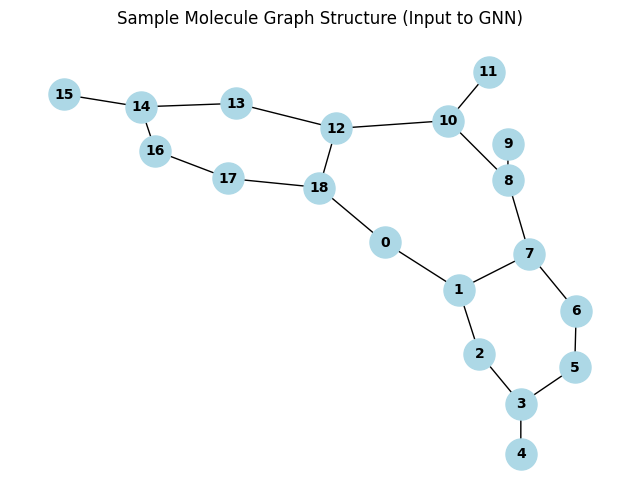

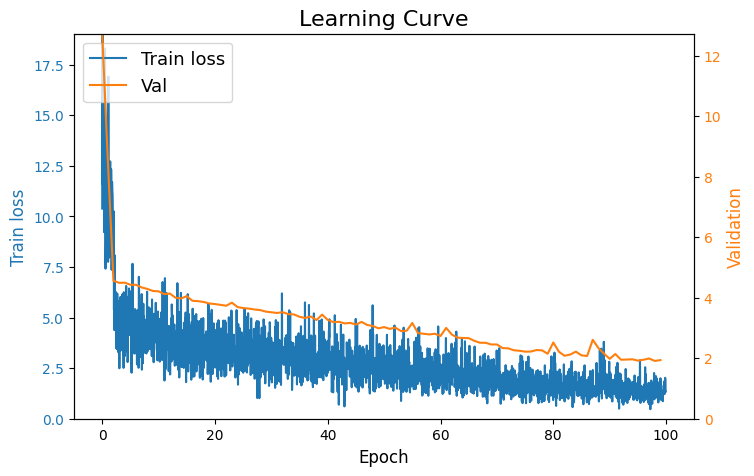

In [25]:
from rdkit.Chem import inchi

num_train = 2*len(graph_dataset)//3

train_dataset_tox = graph_dataset[:num_train]
test_dataset_tox = graph_dataset[num_train:]

# Instantiate the GNN model implemented above with 9 input channels, 1 output channel
model = GNN(in_channels=9, out_channels=1)
model.to(device)

# Train using train_nn method implemented above with the molecules dataset, learning rate 5e-4, MSE loss and for 100 epochs
gnn_molecule_results = train_nn(model,
                                train_dataset_tox,
                                test_dataset_tox,
                                lr=LR,
                                num_epochs=100,
                                graph=True,
                                criterion=nn.MSELoss(),
                                regression=True)

%matplotlib inline
learning_curve(gnn_molecule_results)

### GNN Model Architecture

Let's visualize the structure of the instantiated GNN model, which will be used for solubility prediction. This shows the layers and their connections as defined in the `GNN` class.

In [27]:
# Display the GNN model architecture
print(model)

GNN(
  (conv1): GCNConv()
  (conv2): GCNConv()
  (conv3): GCNConv()
  (conv4): GCNConv()
  (linear1): Linear(in_features=64, out_features=64, bias=True)
  (linear2): Linear(in_features=64, out_features=1, bias=True)
)
